In [3]:
# load the filtered data
# import all semscho papers before any filtering
import pandas as pd
import glob
import json

# ---------------------------------------------------
# 1. Find all batch files
# ---------------------------------------------------

files = glob.glob("../../data/enriched/filtered/enriched_batch_*.jsonl")

print(f"Found {len(files)} files")

# ---------------------------------------------------
# 2. Load all records
# ---------------------------------------------------

records = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"Skipping malformed line in {file}")

# ---------------------------------------------------
# 3. Convert to DataFrame
# ---------------------------------------------------

papers_df = pd.DataFrame(records)

print(papers_df.shape)
print(papers_df.columns)

Found 4 files
(311686, 33)
Index(['paperId', 'title', 'venue', 'year', 'citationCount', 'fieldsOfStudy',
       'publicationTypes', 'authors', 'abstract', 'doi', 'pdf_url', 'oa_id',
       'oa_title', 'oa_publication_year', 'oa_language', 'oa_type',
       'oa_is_retracted', 'oa_cited_by_count',
       'oa_citation_normalized_percentile', 'oa_authors',
       'oa_source_display_name', 'oa_source_issn', 'oa_source_issn_l',
       'oa_source_type', 'oa_source_host_organization_name', 'oa_pdf_url',
       'oa_topics', 'oa_keywords', 'oa_concepts', 'oa_has_pdf',
       'oa_has_grobid_xml', 'oa_content_urls', 'abstract_source'],
      dtype='str')


# topic - score distribution

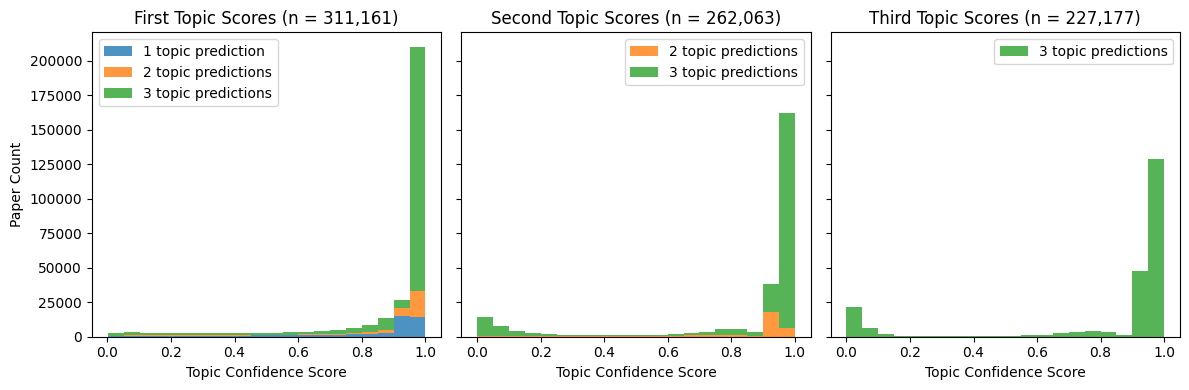

In [31]:
import matplotlib.pyplot as plt

# Keep rows that have at least one topic
with_topics = papers_df[
    papers_df["oa_topics"].apply(
        lambda x: isinstance(x, list) and len(x) > 0
    )
].copy()

# Number of topics/predictions
with_topics["n_topics"] = with_topics["oa_topics"].apply(len)

colors = {
    1: "tab:blue",
    2: "tab:orange",
    3: "tab:green",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, ax in enumerate(axes):

    score_groups = []
    labels = []
    group_colors = []

    # Only include prediction groups that can contribute to this topic
    for n_topics in [1, 2, 3]:

        subset = with_topics[
            (with_topics["n_topics"] == n_topics) &
            (with_topics["n_topics"] > i)
        ]

        if len(subset) == 0:
            continue

        scores = subset["oa_topics"].apply(
            lambda x: x[i]["score"]
        )

        score_groups.append(scores)
        labels.append(
            f"{n_topics} topic prediction{'s' if n_topics != 1 else ''}"
        )
        group_colors.append(colors[n_topics])

    # Total number of papers contributing to this subplot
    total_count = sum(len(group) for group in score_groups)

    # Stacked histogram
    ax.hist(
        score_groups,
        bins=20,
        stacked=True,
        color=group_colors,
        label=labels,
        alpha=0.8
    )

    #ax.set_yscale("log")

    # Title with total count
    topic_name = ["First", "Second", "Third"][i]
    ax.set_title(f"{topic_name} Topic Scores (n = {total_count:,})")

    ax.set_xlabel("Topic Confidence Score")

    if i == 0:
        ax.set_ylabel("Paper Count")

    ax.legend()

plt.tight_layout()
plt.show()

In [32]:
227177/len(papers_df)

0.7288649474150266

# investigate topics

In [2]:
papers_df["oa_topics"].iloc[0]

[{'id': 'https://openalex.org/T11717',
  'display_name': 'Postcolonial and Cultural Literary Studies',
  'score': 0.9700000286102295,
  'subfield': 'Literature and Literary Theory',
  'field': 'Arts and Humanities',
  'domain': 'Social Sciences'}]

In [11]:
sorted_topics = (
    papers_df["oa_topics"]
    .dropna()
    .apply(lambda x: x[0]["display_name"] if x else None)
    .dropna()
    .value_counts()
)

sorted_topics.head(25)

oa_topics
Biblical Studies and Interpretation              2996
Digital Storytelling and Education               2368
Digital Games and Media                          2332
Narrative Theory and Analysis                    2281
Empathy and Medical Education                    2200
Cinema and Media Studies                         2133
Jewish and Middle Eastern Studies                1981
Asian Culture and Media Studies                  1968
Educational Methods and Media Use                1916
Gender, Feminism, and Media                      1822
Language, Metaphor, and Cognition                1692
Memory, Trauma, and Commemoration                1690
Media Influence and Health                       1626
Educator Training and Historical Pedagogy        1615
Islamic Studies and History                      1614
Comics and Graphic Narratives                    1608
Folklore, Mythology, and Literature Studies      1547
Misinformation and Its Impacts                   1543
Contemporary Liter

In [16]:
# Convert to DataFrame and keep the topic name
sorted_topics = sorted_topics.reset_index()
sorted_topics.columns = ["oa_topic", "count"]

# Add rank based on the existing sorting
sorted_topics["rank"] = range(1, len(sorted_topics) + 1)

In [17]:
sorted_topics.head()

,oa_topic,count,rank
0,Biblical Studies and Interpretation,2996,1
1,Digital Storytelling and Education,2368,2
2,Digital Games and Media,2332,3
3,Narrative Theory and Analysis,2281,4
4,Empathy and Medical Education,2200,5


In [12]:
topics = (
    papers_df["oa_topics"]
    .dropna()
    .explode()
    .dropna()
)

In [13]:

weighted_topics = (
    topics
    .apply(lambda x: pd.Series({
        "topic": x["display_name"],
        "score": x["score"]
    }))
    .groupby("topic")["score"]
    .sum()
    .sort_values(ascending=False)
)

weighted_topics.head(25)

topic
Digital Storytelling and Education             4918.094701
Digital Games and Media                        4647.275099
Cinema and Media Studies                       4350.801200
Gender, Feminism, and Media                    4304.577201
Narrative Theory and Analysis                  4207.287601
Biblical Studies and Interpretation            3959.166802
Language, Metaphor, and Cognition              3694.203301
Jewish and Middle Eastern Studies              3597.249401
Media Studies and Communication                3579.550099
Memory, Trauma, and Commemoration              3273.606901
Asian Culture and Media Studies                3255.013198
Empathy and Medical Education                  3219.971299
Media, Gender, and Advertising                 3182.023800
Educator Training and Historical Pedagogy      3176.372100
Media Influence and Health                     3162.091802
Islamic Studies and History                    3074.591701
Folklore, Mythology, and Literature Studies    303

In [18]:
weighted_topics = weighted_topics.reset_index()
weighted_topics.columns = ["oa_topic", "weighted_count"]

weighted_topics["rank"] = range(1, len(weighted_topics) + 1)

In [19]:
merged = (
    sorted_topics
    .merge(
        weighted_topics,
        on="rank",
        how="outer",
        suffixes=("_unweighted", "_weighted")
    )
    .sort_values("rank")
    .reset_index(drop=True)
)

In [21]:
merged.head(25)

,oa_topic_unweighted,count,rank,oa_topic_weighted,weighted_count
0,Biblical Studies and Interpretation,2996.0,1,Digital Storytelling and Education,4918.094701
1,Digital Storytelling and Education,2368.0,2,Digital Games and Media,4647.275099
2,Digital Games and Media,2332.0,3,Cinema and Media Studies,4350.801200
3,Narrative Theory and Analysis,2281.0,4,"Gender, Feminism, and Media",4304.577201
4,Empathy and Medical Education,2200.0,5,Narrative Theory and Analysis,4207.287601
5,Cinema and Media Studies,2133.0,6,Biblical Studies and Interpretation,3959.166802
6,Jewish and Middle Eastern Studies,1981.0,7,"Language, Metaphor, and Cognition",3694.203301
7,Asian Culture and Media Studies,1968.0,8,Jewish and Middle Eastern Studies,3597.249401
8,Educational Methods and Media Use,1916.0,9,Media Studies and Communication,3579.550099
9,"Gender, Feminism, and Media",1822.0,10,"Memory, Trauma, and Commemoration",3273.606901


In [ ]:
# Round weighted count to one decimal place
merged["weighted_count"] = merged["weighted_count"].round(1)

# Set desired column order and names
merged = merged[
    [
        "rank",
        "oa_topic_unweighted",
        #"count",
        "oa_topic_weighted",
        #"weighted_count",
    ]
].rename(columns={
    "oa_topic_unweighted": "primary_topic",
    "oa_topic_weighted": "weighted_topic",
})

merged.head(30)

In [27]:
merged[merged["primary_topic"] == "Media, Gender, and Advertising"]

,rank,primary_topic,count,weighted_topic,weighted_count
55,56,"Media, Gender, and Advertising",905.0,Medieval Literature and History,1893.2


In [28]:
merged[merged["primary_topic"] == "Migration, Refugees, and Integration"]

,rank,primary_topic,count,weighted_topic,weighted_count
28,29,"Migration, Refugees, and Integration",1242.0,Discourse Analysis in Language Studies,2568.8


In [29]:
merged[merged["primary_topic"] == "Social Media and Politics"]

,rank,primary_topic,count,weighted_topic,weighted_count
8,9,Educational Methods and Media Use,1916.0,Media Studies and Communication,3579.6


In [32]:
merged[merged["weighted_topic"] == "Educational Methods and Media Use"]

,rank,primary_topic,count,weighted_topic,weighted_count
22,23,Classical Antiquity Studies,1416.0,Educational Methods and Media Use,2727.0


In [33]:
merged[merged["weighted_topic"] == "Comics and Graphic Narratives"]

,rank,primary_topic,count,weighted_topic,weighted_count
20,21,South Asian Cinema and Culture,1490.0,Comics and Graphic Narratives,2764.2


In [34]:
merged[merged["weighted_topic"] == "Misinformation and Its Impacts"]

,rank,primary_topic,count,weighted_topic,weighted_count
31,32,Gothic Literature and Media Analysis,1185.0,Misinformation and Its Impacts,2471.1


In [35]:
merged[merged["weighted_topic"] == "Race, History, and American Society"]

,rank,primary_topic,count,weighted_topic,weighted_count
29,30,Medieval Literature and History,1232.0,"Race, History, and American Society",2522.1


In [24]:
print(
    merged.head(25).to_latex(
        index=False,
        escape=True
    )
)

\begin{tabular}{rlrlr}
\toprule
rank & primary\_topic & count & weighted\_topic & weighted\_count \\
\midrule
1 & Biblical Studies and Interpretation & 2996.000000 & Digital Storytelling and Education & 4918.100000 \\
2 & Digital Storytelling and Education & 2368.000000 & Digital Games and Media & 4647.300000 \\
3 & Digital Games and Media & 2332.000000 & Cinema and Media Studies & 4350.800000 \\
4 & Narrative Theory and Analysis & 2281.000000 & Gender, Feminism, and Media & 4304.600000 \\
5 & Empathy and Medical Education & 2200.000000 & Narrative Theory and Analysis & 4207.300000 \\
6 & Cinema and Media Studies & 2133.000000 & Biblical Studies and Interpretation & 3959.200000 \\
7 & Jewish and Middle Eastern Studies & 1981.000000 & Language, Metaphor, and Cognition & 3694.200000 \\
8 & Asian Culture and Media Studies & 1968.000000 & Jewish and Middle Eastern Studies & 3597.200000 \\
9 & Educational Methods and Media Use & 1916.000000 & Media Studies and Communication & 3579.600000 \\

# nr topics vs subfields vs fields

In [4]:
# 1. Number of topics per paper
topic_lengths = papers_df["oa_topics"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
topic_counts = topic_lengths.value_counts().sort_index()

# 2. Number of unique subfields per paper
subfield_counts = papers_df["oa_topics"].apply(
    lambda x: len(set(item["subfield"] for item in x))
    if isinstance(x, list) else 0
)
subfield_counts = subfield_counts.value_counts().sort_index()

# 3. Number of unique fields per paper
field_counts = papers_df["oa_topics"].apply(
    lambda x: len(set(item["field"] for item in x))
    if isinstance(x, list) else 0
)
field_counts = field_counts.value_counts().sort_index()

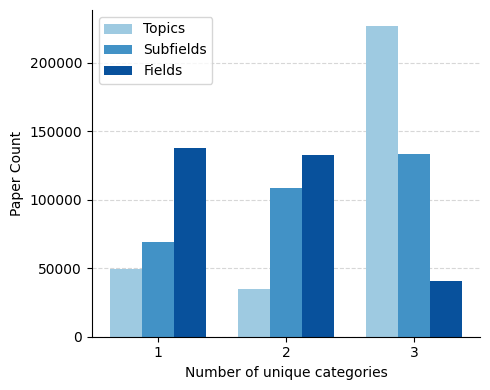

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Common x-axis
max_n = max(
    topic_counts.index.max(),
    subfield_counts.index.max(),
    field_counts.index.max()
)

x = np.arange(1, max_n + 1)

# Align distributions and fill missing values with 0
topics = topic_counts.reindex(x, fill_value=0)
subfields = subfield_counts.reindex(x, fill_value=0)
fields = field_counts.reindex(x, fill_value=0)


# Plot
fig, ax = plt.subplots(figsize=(5, 4))

width = 0.25

colors = ["#9ECAE1", "#4292C6", "#08519C"] #three shades of blue

ax.bar(
    x - width,
    topics,
    width,
    label="Topics",
    color = colors[0]
)

ax.bar(
    x,
    subfields,
    width,
    label="Subfields",
    color = colors[1]
)

ax.bar(
    x + width,
    fields,
    width,
    label="Fields",
    color = colors[2]
)


# Labels
ax.set_xlabel(
    "Number of unique categories"
)
ax.set_ylabel("Paper Count")


ax.set_xticks(x)
ax.legend()

# Grid
ax.set_axisbelow(True)
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Remove unnecessary top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# investigate subfields

In [19]:
sorted_subfields = (
    papers_df["oa_topics"]
    .dropna()
    .apply(lambda x: x[0]["subfield"] if x else None)
    .dropna()
    .value_counts()
)

sorted_subfields.head(20)

oa_topics
Sociology and Political Science                         51062
Literature and Literary Theory                          20900
Political Science and International Relations           17991
Education                                               15116
Cultural Studies                                        10475
Clinical Psychology                                      9538
Social Psychology                                        8023
Philosophy                                               7380
General Health Professions                               7137
Anthropology                                             6973
History                                                  6919
Gender Studies                                           6832
Visual Arts and Performing Arts                          6210
Economics and Econometrics                               5361
Information Systems                                      5087
Developmental and Educational Psychology                 501

In [30]:
weighted_subfields = (
    topics
    .apply(lambda x: pd.Series({
        "subfield": x["subfield"],
        "score": x["score"]
    }))
    .groupby("subfield")["score"]
    .sum()
    .sort_values(ascending=False)
    
)

weighted_subfields.head(20)

TypeError: 'float' object is not subscriptable

# investigate fields and domain

In [22]:
sorted_fields = (
    papers_df["oa_topics"]
    .dropna()
    .apply(lambda x: x[0]["field"] if x else None)
    .dropna()
    .value_counts()
)

sorted_fields

oa_topics
Social Sciences                                 132741
Arts and Humanities                              63827
Psychology                                       27361
Medicine                                         22762
Computer Science                                 13902
Health Professions                               12519
Business, Management and Accounting               7248
Economics, Econometrics and Finance               7181
Environmental Science                             5554
Neuroscience                                      3240
Agricultural and Biological Sciences              3015
Engineering                                       2943
Biochemistry, Genetics and Molecular Biology      2127
Decision Sciences                                 1699
Earth and Planetary Sciences                      1225
Physics and Astronomy                              868
Nursing                                            802
Mathematics                                        501


In [33]:
weighted_fields = (
    topics
    .apply(lambda x: pd.Series({
        "field": x["field"],
        "score": x["score"]
    }))
    .groupby("field")["score"]
    .sum()
    .sort_values(ascending=False)
    
)

weighted_fields.head(20)

field
Social Sciences                                 297526.669547
Arts and Humanities                             135881.339920
Psychology                                       61485.195411
Medicine                                         41207.127606
Computer Science                                 31965.759695
Health Professions                               27233.170906
Business, Management and Accounting              16465.787603
Economics, Econometrics and Finance              15328.103703
Environmental Science                            12106.631505
Neuroscience                                      7441.390702
Agricultural and Biological Sciences              6767.251300
Engineering                                       6460.779399
Biochemistry, Genetics and Molecular Biology      4613.380900
Decision Sciences                                 3561.057201
Earth and Planetary Sciences                      3003.014600
Physics and Astronomy                             1745.091200
Nu

In [6]:
import matplotlib.pyplot as plt

field_domain = (
    papers_df["oa_topics"]
    .dropna()
    .apply(lambda x: (x[0]["field"], x[0]["domain"]) if x else None)
    .dropna()
    .apply(pd.Series)
    .set_axis(["field", "domain"], axis=1)
)


field_counts = (
    field_domain
    .groupby(["field", "domain"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

field_counts

,field,domain,count
24,Social Sciences,Social Sciences,132741
1,Arts and Humanities,Social Sciences,63827
23,Psychology,Social Sciences,27361
18,Medicine,Health Sciences,22762
6,Computer Science,Physical Sciences,13902
14,Health Professions,Health Sciences,12519
3,"Business, Management and Accounting",Social Sciences,7248
10,"Economics, Econometrics and Finance",Social Sciences,7181
13,Environmental Science,Physical Sciences,5554
19,Neuroscience,Life Sciences,3240


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

field_domain = (
    papers_df["oa_topics"]
    .apply(
        lambda x: (
            x[0].get("field", "n/a"),
            x[0].get("domain", "n/a")
        )
        if isinstance(x, list) and len(x) > 0
        else ("n/a", "n/a")
    )
    .apply(pd.Series)
    .set_axis(["field", "domain"], axis=1)
)

# Also classify actual NaN values as "n/a"
field_domain = field_domain.fillna("n/a")

field_counts = (
    field_domain
    .groupby(["field", "domain"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

field_counts

,field,domain,count
24,Social Sciences,Social Sciences,132741
1,Arts and Humanities,Social Sciences,63827
23,Psychology,Social Sciences,27361
18,Medicine,Health Sciences,22762
6,Computer Science,Physical Sciences,13902
14,Health Professions,Health Sciences,12519
3,"Business, Management and Accounting",Social Sciences,7248
10,"Economics, Econometrics and Finance",Social Sciences,7181
13,Environmental Science,Physical Sciences,5554
19,Neuroscience,Life Sciences,3240


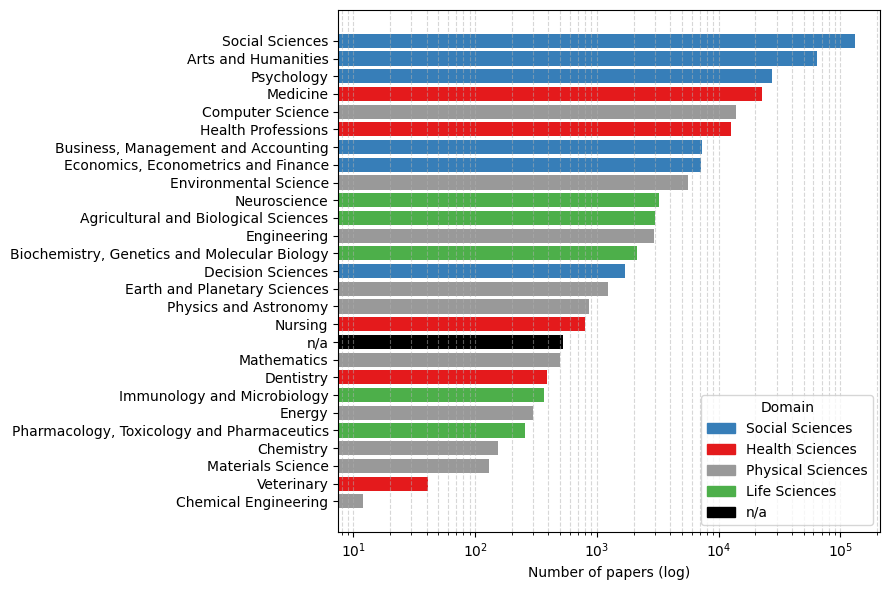

In [14]:
plt.figure(figsize=(9, 6))

domains = field_counts["domain"].unique() #['Social Sciences', 'Health Sciences', 'Physical Sciences', 'Life Sciences']
colors = ["#377EB8", "#E41A1C", "#999999", "#4DAF4A", "#000000"]#plt.cm.tab10(range(len(domains)))
domain_colors = dict(zip(domains, colors))

plt.barh(
    field_counts["field"][::-1],
    field_counts["count"][::-1],
    color=[
        domain_colors[d]
        for d in field_counts["domain"][::-1]
    ]
)

plt.xscale("log")

plt.grid(
    axis="x",
    which="both",
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Number of papers (log)")
plt.ylabel("")
#plt.title("Papers by field")

handles = [
    plt.Rectangle((0, 0), 1, 1, color=domain_colors[d])
    for d in domains
]
plt.legend(handles, domains, title="Domain")

plt.tight_layout()
plt.show()